<a href="https://colab.research.google.com/github/Liebert27/DescriptiveStatisticsEcommerce/blob/main/StatistikaProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Langkah 1: Import library dan baca data


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_raw = pd.read_csv("ecommerce_customer_behavior_dataset_v2.csv")
df = df_raw.copy()
print(df.shape)

(17049, 18)


## Langkah 2: Cek struktur data

In [ ]:
df.info()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

## Langkah 3: Cleaning data

### 3a. Missing value dan duplikat

In [ ]:
print(df.isna().sum())
print("Duplikat Order_ID:", df["Order_ID"].duplicated().sum())
print("Duplikat baris penuh:", df.duplicated().sum())

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64
Duplikat Order_ID: 0
Duplikat baris penuh: 0


### 3b. Rapikan tipe data dan teks

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Device_Type"] = df["Device_Type"].str.strip().str.title()
df["Session_Duration_Minutes"] = pd.to_numeric(df["Session_Duration_Minutes"], errors="coerce")
print(df["Device_Type"].unique())

['Mobile' 'Desktop' 'Tablet']


### 3c. Validasi nilai yang tidak masuk akal

In [ ]:
print("Durasi <= 0:", (df["Session_Duration_Minutes"] <= 0).sum())
print(df["Session_Duration_Minutes"].agg(["min", "max"]))
print("Kolom Session_Duration kosong:", df["Session_Duration_Minutes"].isna().sum())

Durasi <= 0: 0
min     4
max    26
Name: Session_Duration_Minutes, dtype: int64
Kolom Session_Duration kosong: 0


### 3d. Ambil kolom yang dipakai

In [ ]:
df_clean = df[["Order_ID", "Device_Type", "Session_Duration_Minutes", "Pages_Viewed"]].dropna()
print("Baris sebelum:", len(df_raw), "| sesudah:", len(df_clean))
df_clean.to_csv("data_bersih.csv", index=False)

Baris sebelum: 17049 | sesudah: 17049


## Langkah 4: Tabel frekuensi perangkat

In [ ]:
kol = "Session_Duration_Minutes"
order = ["Mobile", "Desktop", "Tablet"]

frek = df_clean["Device_Type"].value_counts().loc[order]
persen = (frek / frek.sum() * 100).round(1)
tabel_frek = pd.DataFrame({"Frekuensi": frek, "Persentase (%)": persen})
print(tabel_frek)

             Frekuensi  Persentase (%)
Device_Type                           
Mobile            9543            56.0
Desktop           5845            34.3
Tablet            1661             9.7


## 5. Statistika Deskriptif

### 5a. Keseluruhan

In [ ]:
dt = df_clean[kol]
stats = dt.describe()
stats["Standard Error"] = dt.sem()
stats["Median"] = dt.median()
stats["Mode"] = dt.mode().iloc[0]
stats["variance"] = dt.var()
stats["range"] = dt.max() - dt.min()
stats["IQR"] = dt.quantile(0.75) - dt.quantile(0.25)
stats["CV (%)"] = dt.std() / dt.mean() * 100
stats["skewness"] = dt.skew()
stats["kurtosis"] = dt.kurtosis()
print(stats.round(3))

count             17049.000
mean                 14.536
std                   2.926
min                   4.000
25%                  13.000
50%                  15.000
75%                  17.000
max                  26.000
Standard Error        0.022
Median               15.000
Mode                 14.000
variance              8.559
range                22.000
IQR                   4.000
CV (%)               20.127
skewness             -0.008
kurtosis              0.038
Name: Session_Duration_Minutes, dtype: float64


### 5b. Per perangkat

In [ ]:
grp = df_clean.groupby("Device_Type")[kol]
ringkasan = grp.agg(n="count", mean="mean", median="median",
                    std="std", min="min", max="max").loc[order]
ringkasan["SE"] = grp.sem()
ringkasan["CV_%"] = ringkasan["std"] / ringkasan["mean"] * 100
ringkasan["skew"] = grp.skew()
ringkasan["kurt"] = grp.apply(lambda s: s.kurtosis())
print(ringkasan.round(3))

                n    mean  median    std  min  max     SE    CV_%   skew  \
Device_Type                                                                
Mobile       9543  14.525    15.0  2.924    4   25  0.030  20.133 -0.007   
Desktop      5845  14.532    15.0  2.945    5   26  0.039  20.268  0.010   
Tablet       1661  14.610    15.0  2.863    6   23  0.070  19.596 -0.080   

              kurt  
Device_Type         
Mobile       0.072  
Desktop      0.056  
Tablet      -0.238  


## Langkah 6: Deteksi outlier (aturan 1,5 × IQR)

In [ ]:
q1, q3 = dt.quantile(0.25), dt.quantile(0.75)
iqr = q3 - q1
bawah, atas = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier = df_clean[(dt < bawah) | (dt > atas)]
print("Batas:", bawah, "-", atas, "| Jumlah outlier:", len(outlier))
print(outlier["Device_Type"].value_counts())

Batas: 7.0 - 23.0 | Jumlah outlier: 85
Device_Type
Mobile     51
Desktop    31
Tablet      3
Name: count, dtype: int64


## Langkah 7: Dashboard

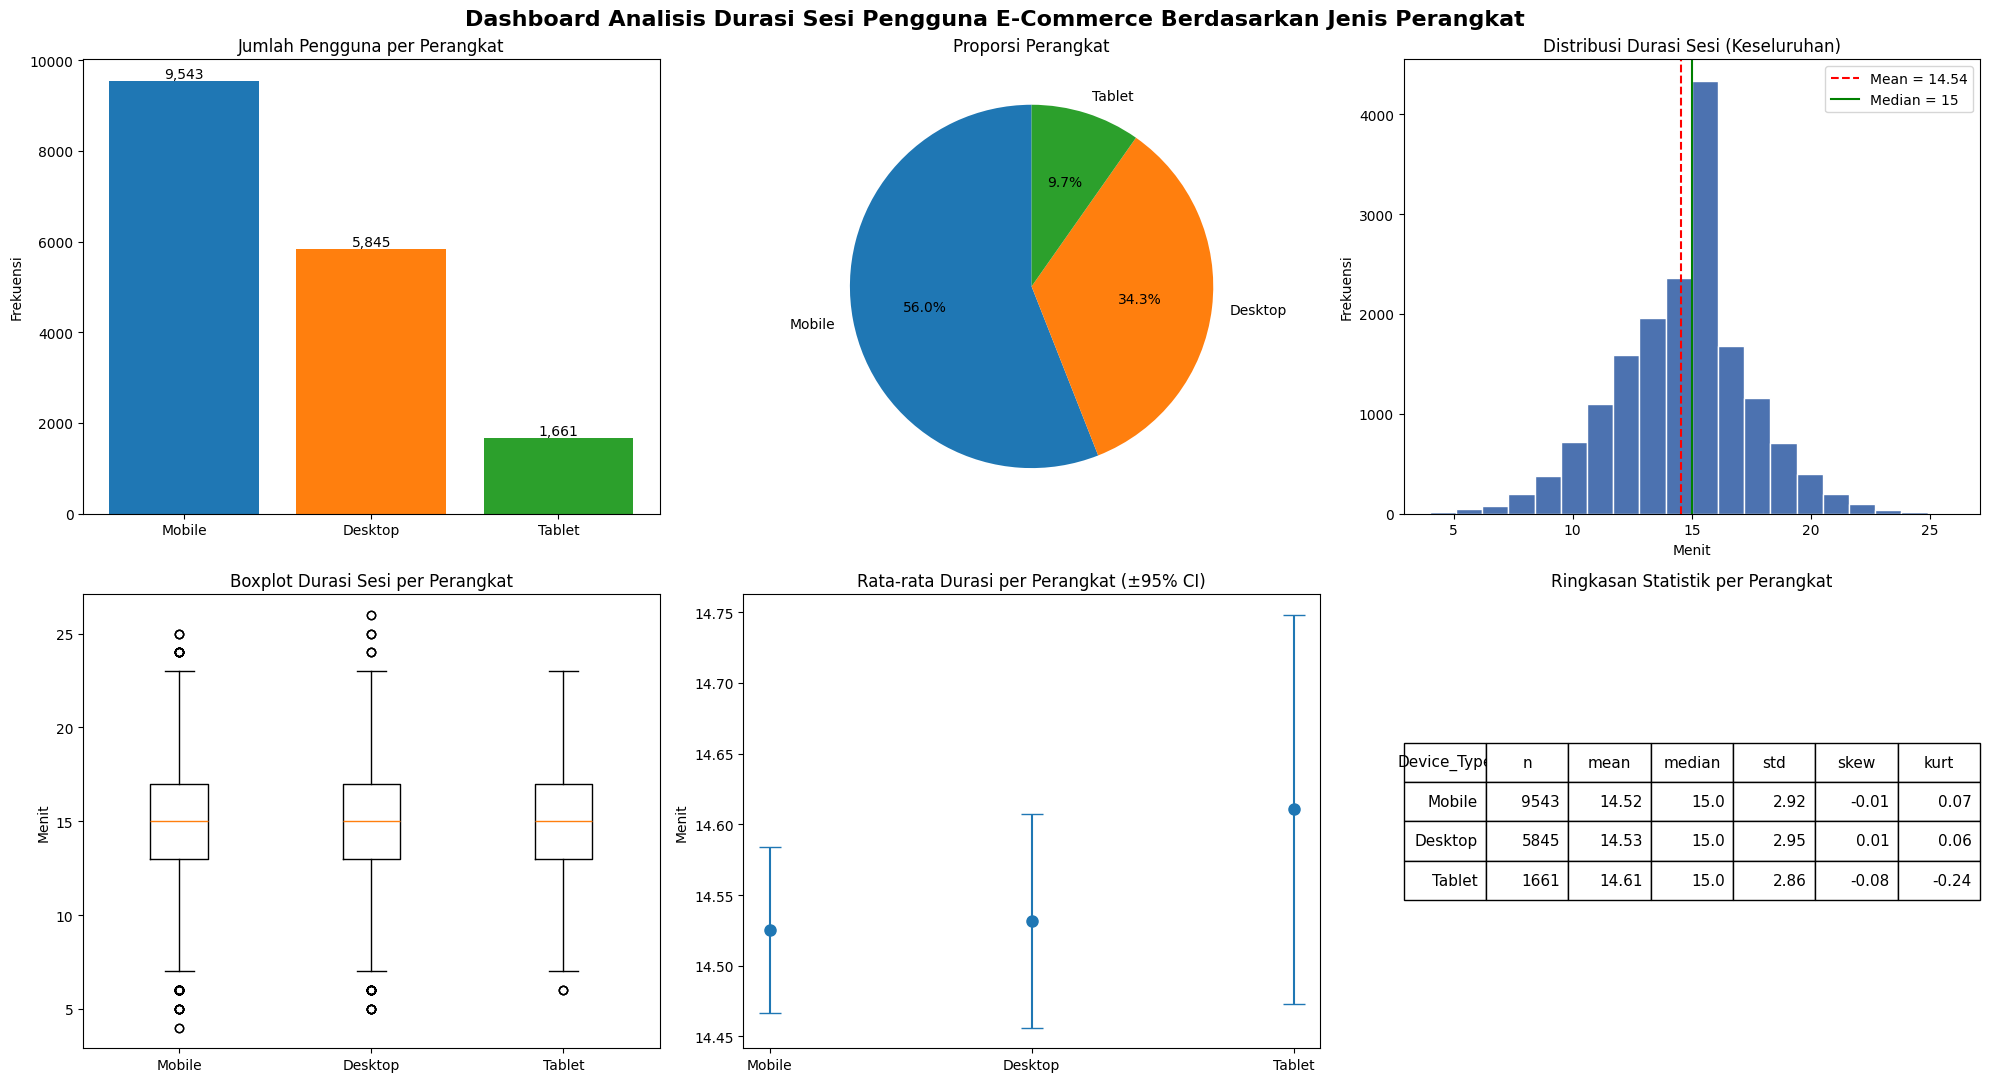

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Dashboard Analisis Durasi Sesi Pengguna E-Commerce Berdasarkan Jenis Perangkat",
             fontsize=16, fontweight="bold")

# Panel 1: Jumlah pengguna per perangkat (bar)
ax[0, 0].bar(order, frek.values, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
ax[0, 0].set_title("Jumlah Pengguna per Perangkat")
ax[0, 0].set_ylabel("Frekuensi")
for i, v in enumerate(frek.values):
    ax[0, 0].text(i, v, f"{v:,}", ha="center", va="bottom")

# Panel 2: Proporsi perangkat (pie)
ax[0, 1].pie(frek.values, labels=order, autopct="%1.1f%%", startangle=90)
ax[0, 1].set_title("Proporsi Perangkat")

# Panel 3: Histogram durasi sesi
ax[0, 2].hist(dt, bins=20, color="#4c72b0", edgecolor="white")
ax[0, 2].axvline(dt.mean(), color="red", linestyle="--", label=f"Mean = {dt.mean():.2f}")
ax[0, 2].axvline(dt.median(), color="green", linestyle="-", label=f"Median = {dt.median():.0f}")
ax[0, 2].set_title("Distribusi Durasi Sesi (Keseluruhan)")
ax[0, 2].set_xlabel("Menit")
ax[0, 2].set_ylabel("Frekuensi")
ax[0, 2].legend()

# Panel 4: Boxplot per perangkat
data_box = [df_clean.loc[df_clean["Device_Type"] == d, kol] for d in order]
ax[1, 0].boxplot(data_box)
ax[1, 0].set_xticklabels(order)
ax[1, 0].set_title("Boxplot Durasi Sesi per Perangkat")
ax[1, 0].set_ylabel("Menit")

# Panel 5: Rata-rata dan 95% CI per perangkat
ci = 1.96 * ringkasan["SE"]
ax[1, 1].errorbar(order, ringkasan["mean"], yerr=ci, fmt="o", capsize=8, markersize=8)
ax[1, 1].set_title("Rata-rata Durasi per Perangkat (±95% CI)")
ax[1, 1].set_ylabel("Menit")

# Panel 6: Tabel ringkasan
ax[1, 2].axis("off")
tabel = ringkasan[["n", "mean", "median", "std", "skew", "kurt"]].round(2).reset_index()
t = ax[1, 2].table(cellText=tabel.values, colLabels=tabel.columns, loc="center")
t.auto_set_font_size(False)
t.set_fontsize(11)
t.scale(1, 2)
ax[1, 2].set_title("Ringkasan Statistik per Perangkat")

plt.tight_layout()
plt.savefig("dashboard_durasi_sesi.png", dpi=150)
plt.show()